# Klasifikasi Kematangan Tapai - Random Forest

Notebook ini menggunakan **Random Forest Classifier** dari scikit-learn — sebuah ensemble method berbasis decision tree — untuk memprediksi status kematangan tapai.

Random Forest dipilih karena:
- Robust terhadap outlier dan tidak memerlukan normalisasi
- Memberikan informasi **feature importance** yang berguna
- Umumnya lebih akurat dibanding model linear untuk data non-linear

## Dataset
- **Fitur:** `jam`, `suhu`, `kelembaban`, `kadar_gas`
- **Target:** `status_kematangan` (belum matang, matang, terlalu matang)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import plot_tree

plt.style.use('seaborn-v0_8')
print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Load & Eksplorasi Data

In [2]:
df = pd.read_csv('../dataset/dataset_kematangan_tapai_v2.csv')
print('Shape:', df.shape)
df.head()

Shape: (600, 6)


,percobaan,jam,suhu,kelembaban,kadar_gas,status_kematangan
0,1,1,28.73,78.77,0.02,belum matang
1,1,2,28.51,78.62,0.01,belum matang
2,1,3,28.33,78.22,0.01,belum matang
3,1,4,29.20,78.46,0.01,belum matang
4,1,5,28.42,78.65,0.00,belum matang


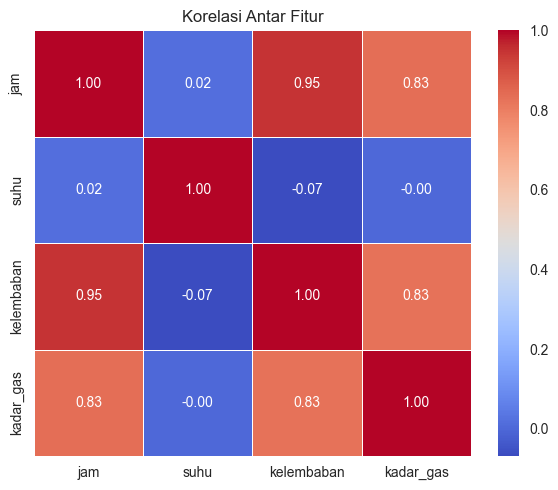

In [3]:
# Heatmap korelasi
corr = df[['jam', 'suhu', 'kelembaban', 'kadar_gas']].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Korelasi Antar Fitur')
plt.tight_layout()
plt.savefig('plot_rf_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

/var/folders/2g/94srnc3562l2bwpq53klrv340000gn/T/ipykernel_8731/3802646526.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='status_kematangan', y=feat,
/var/folders/2g/94srnc3562l2bwpq53klrv340000gn/T/ipykernel_8731/3802646526.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='status_kematangan', y=feat,
/var/folders/2g/94srnc3562l2bwpq53klrv340000gn/T/ipykernel_8731/3802646526.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='status_kematangan', y=feat,
/var/folders/2g/94srnc3562l2bwpq53klrv340000gn

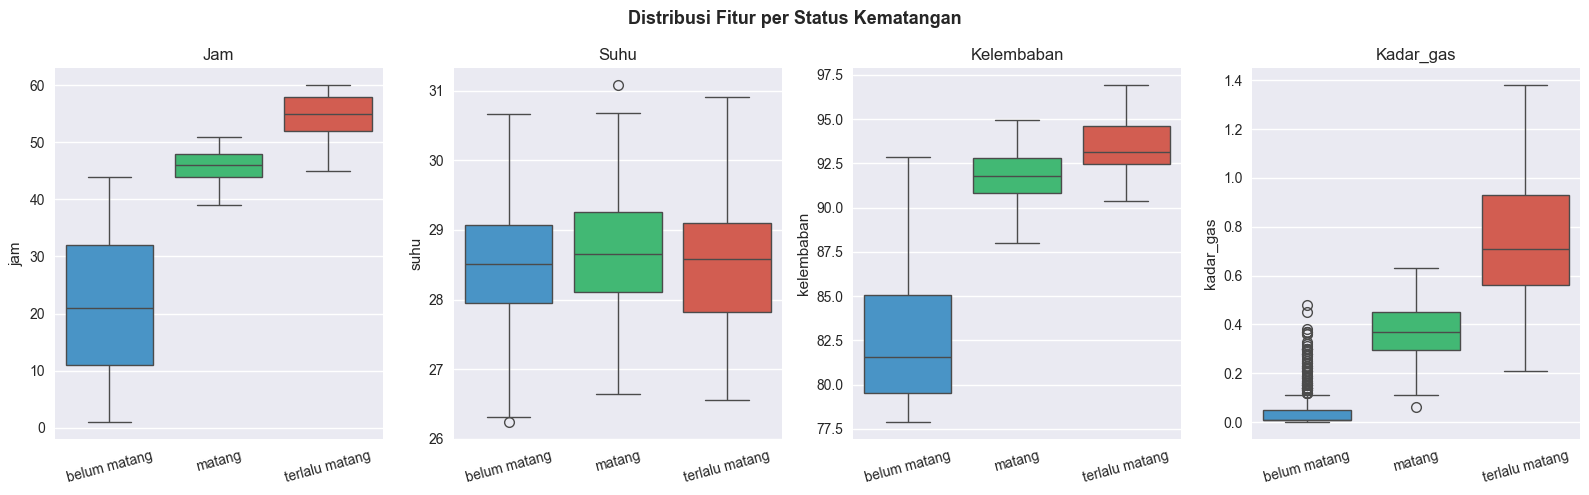

In [4]:
# Distribusi fitur per status (boxplot)
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
features = ['jam', 'suhu', 'kelembaban', 'kadar_gas']
palette = {'belum matang': '#3498db', 'matang': '#2ecc71', 'terlalu matang': '#e74c3c'}

for ax, feat in zip(axes, features):
    sns.boxplot(data=df, x='status_kematangan', y=feat,
                palette=palette, ax=ax,
                order=['belum matang', 'matang', 'terlalu matang'])
    ax.set_title(feat.capitalize())
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Distribusi Fitur per Status Kematangan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_rf_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Preprocessing

In [5]:
label_map = {'belum matang': 0, 'matang': 1, 'terlalu matang': 2}
df['label'] = df['status_kematangan'].map(label_map)

X = df[['jam', 'suhu', 'kelembaban', 'kadar_gas']].values
y = df['label'].values

# Random Forest tidak memerlukan normalisasi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (480, 4) | Test: (120, 4)


## 3. Training Random Forest

In [6]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

cv_scores = cross_val_score(rf, X_train, y_train, cv=5)
print(f'Test Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'CV Score (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Test Accuracy : 0.9167 (91.67%)
CV Score (5-fold): 0.9354 ± 0.0212


## 4. Evaluasi Model

In [7]:
target_names = ['belum matang', 'matang', 'terlalu matang']
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=target_names))

Classification Report:
                precision    recall  f1-score   support

  belum matang       0.95      0.99      0.97        84
        matang       0.62      0.62      0.62        13
terlalu matang       0.95      0.83      0.88        23

      accuracy                           0.92       120
     macro avg       0.84      0.81      0.82       120
  weighted avg       0.92      0.92      0.92       120



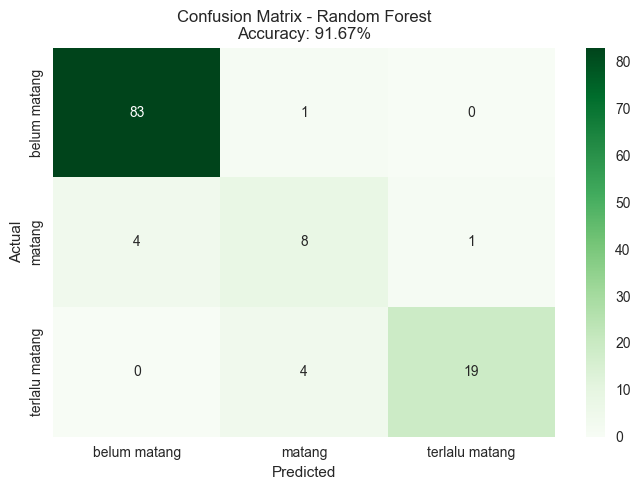

In [8]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - Random Forest\nAccuracy: {accuracy*100:.2f}%')
plt.tight_layout()
plt.savefig('plot_rf_cm.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Feature Importance

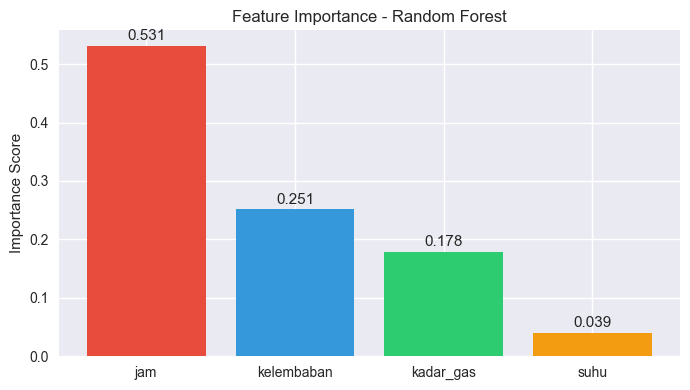

In [9]:
feature_names = ['jam', 'suhu', 'kelembaban', 'kadar_gas']
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(range(len(feature_names)),
              importances[indices],
              color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'][:len(feature_names)])
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels([feature_names[i] for i in indices])
ax.set_title('Feature Importance - Random Forest')
ax.set_ylabel('Importance Score')

for bar, imp in zip(bars, importances[indices]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{imp:.3f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('plot_rf_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Visualisasi Salah Satu Decision Tree

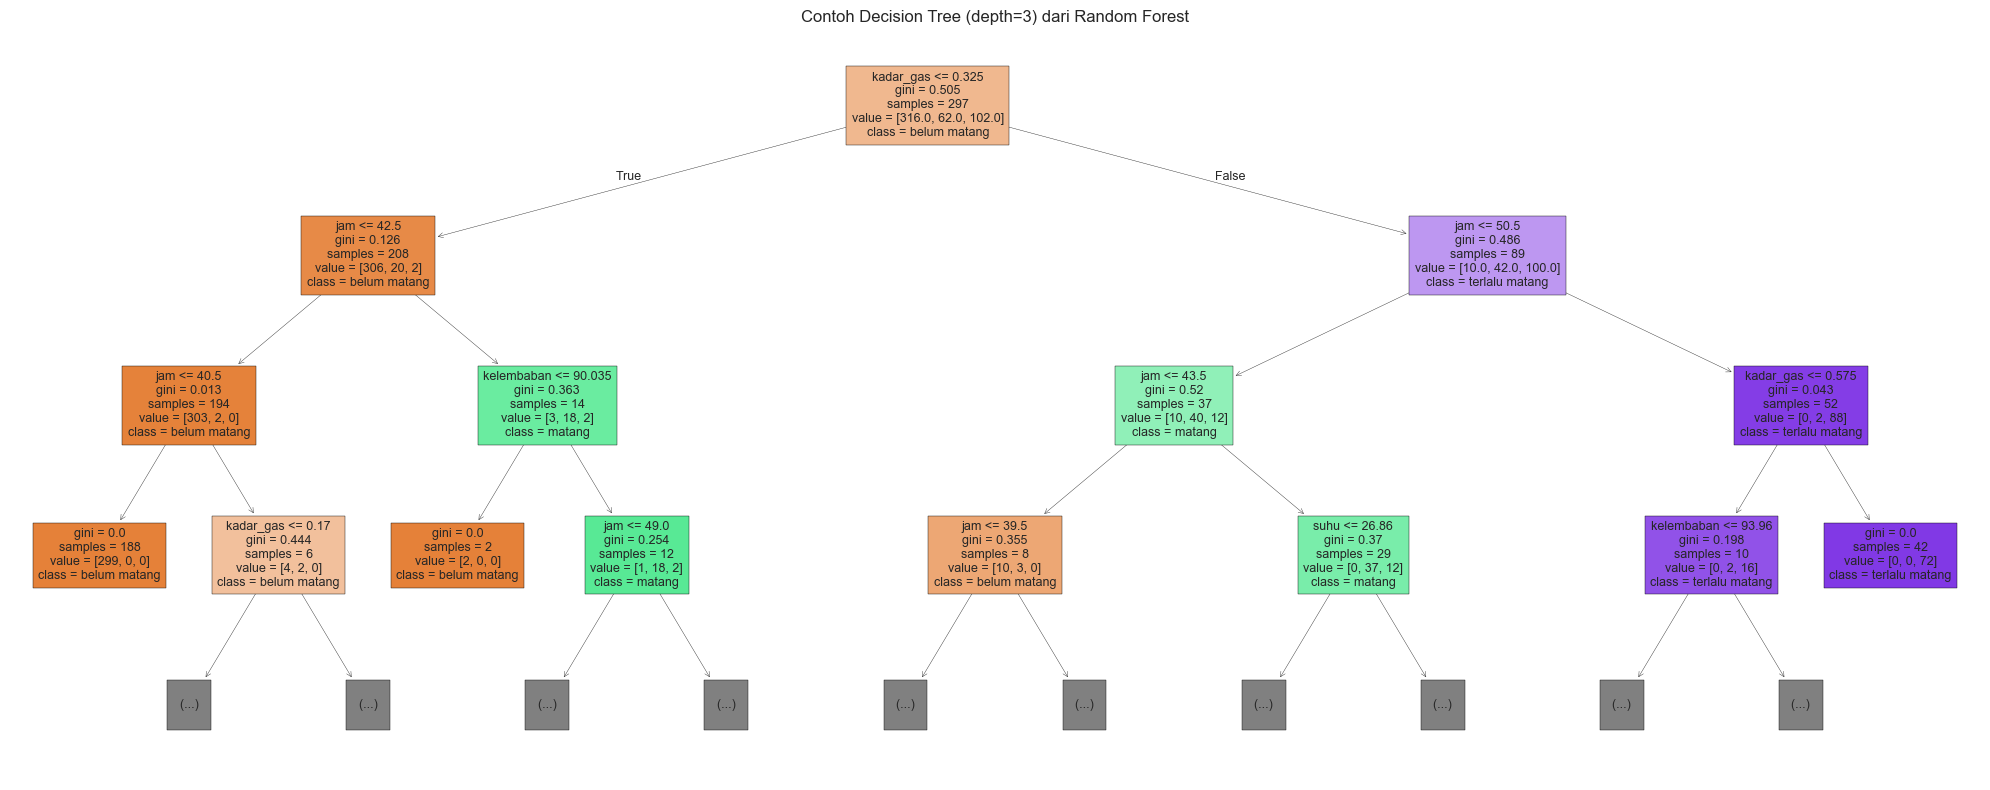

In [10]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    rf.estimators_[0],
    max_depth=3,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Contoh Decision Tree (depth=3) dari Random Forest')
plt.tight_layout()
plt.savefig('plot_rf_tree.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Perbandingan Jumlah Trees vs Akurasi

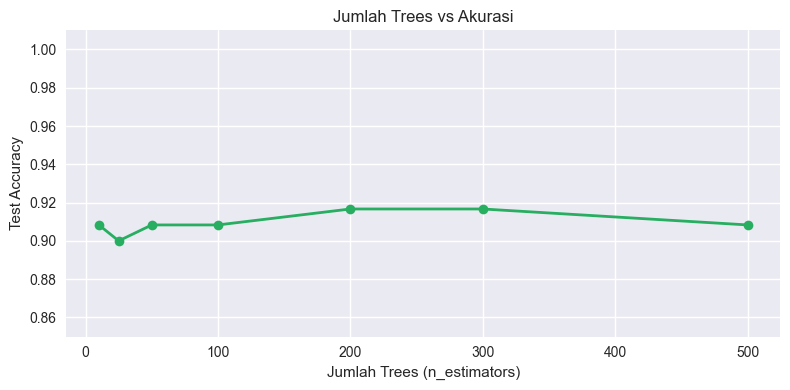

In [11]:
n_trees = [10, 25, 50, 100, 200, 300, 500]
accs = []

for n in n_trees:
    rf_tmp = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf_tmp.fit(X_train, y_train)
    accs.append(accuracy_score(y_test, rf_tmp.predict(X_test)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_trees, accs, 'o-', color='#27ae60', linewidth=2)
ax.set_xlabel('Jumlah Trees (n_estimators)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Jumlah Trees vs Akurasi')
ax.set_ylim([0.85, 1.01])
plt.tight_layout()
plt.savefig('plot_rf_ntrees.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Kesimpulan

Random Forest umumnya menghasilkan akurasi yang lebih tinggi dibanding Logistic Regression dan SVM pada dataset ini karena kemampuannya menangkap relasi **non-linear** dan interaksi antar fitur.

Namun, keterbatasan utama tetap sama: model ini memperlakukan setiap observasi jam secara **independen** tanpa mempertimbangkan konteks urutan temporal fermentasi. Untuk mengatasi ini, diperlukan pendekatan seperti **RNN/LSTM** yang secara eksplisit memodelkan ketergantungan antar waktu.